# **Fashion MNIST Classification using a Convolutional Neural Network (CNN)**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [5]:

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"Training data shape: {x_train.shape}, Labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}, Labels shape: {y_test.shape}")

Training data shape: (60000, 28, 28), Labels shape: (60000,)
Test data shape: (10000, 28, 28), Labels shape: (10000,)


In [6]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [8]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"Reshaped training data: {x_train.shape}")
print(f"Reshaped test data: {x_test.shape}")

Reshaped training data: (60000, 28, 28, 1)
Reshaped test data: (10000, 28, 28, 1)


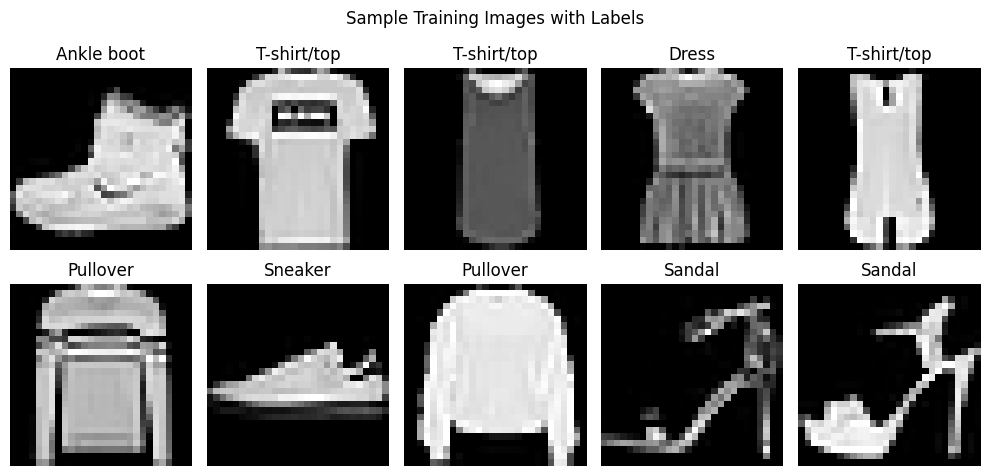

Saved sample images to 'sample_images.png'



In [9]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Training Images with Labels")
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("Saved sample images to 'sample_images.png'\n")

2. BUILD THE CNN MODEL

In [11]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third Convolutional Block (optional extra depth)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

 3. TRAIN THE MODEL

In [12]:
EPOCHS = 20
BATCH_SIZE = 64

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 84s 103ms/step - accuracy: 0.7484 - loss: 0.6895 - val_accuracy: 0.8492 - val_loss: 0.3966 - learning_rate: 0.0010
Epoch 2/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 82s 102ms/step - accuracy: 0.8441 - loss: 0.4296 - val_accuracy: 0.8746 - val_loss: 0.3197 - learning_rate: 0.0010
Epoch 3/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.8676 - loss: 0.3672 - val_accuracy: 0.8871 - val_loss: 0.2923 - learning_rate: 0.0010
Epoch 4/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.8781 - loss: 0.3355 - val_accuracy: 0.8913 - val_loss: 0.2741 - learning_rate: 0.0010
Epoch 5/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.8850 - loss: 0.3143 - val_accuracy: 0.9049 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 6/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.8924 - loss: 0.2990 - val_accuracy: 0.9091 - val_loss: 0.2418 - learning_rate: 0.0010
Epoch 7/20
797/797 ━━━━━━━━━━━━━━━━━━━━ 99s 124ms/step - accuracy: 0.8

4. MODEL EVALUATION

In [14]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}\n")


Test Accuracy: 0.9210
Test Loss: 0.2143



In [15]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


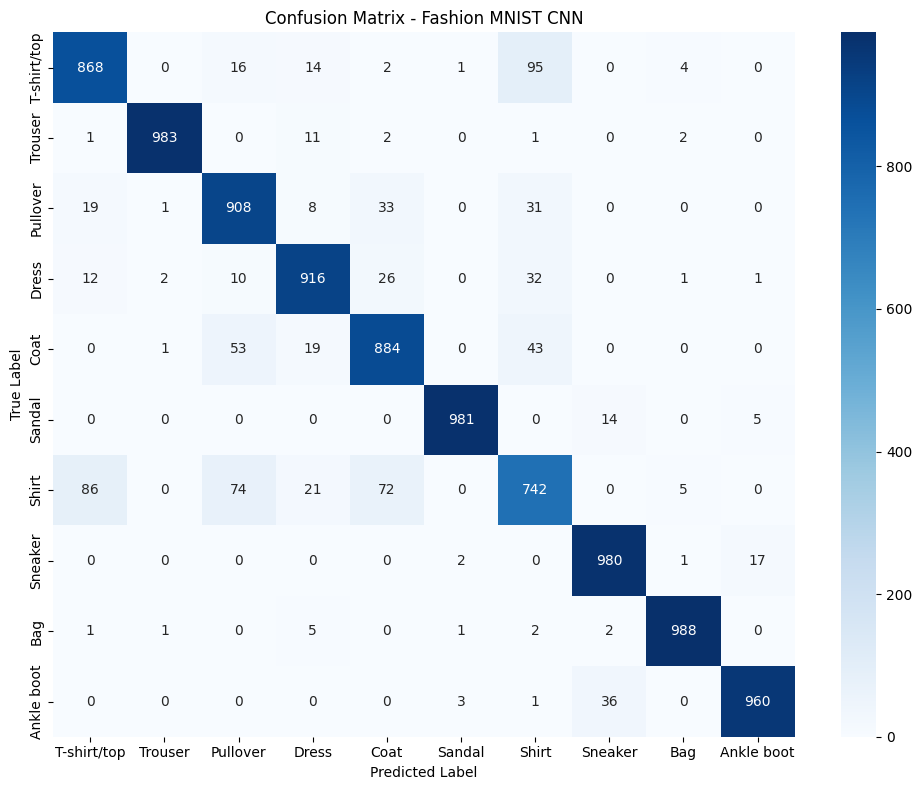

Saved confusion matrix to 'confusion_matrix.png'



In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Fashion MNIST CNN')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved confusion matrix to 'confusion_matrix.png'\n")

In [17]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.87      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.91      0.88      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.87      0.88      0.88      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.78      0.74      0.76      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



 5. VISUALIZATION AND ANALYSIS

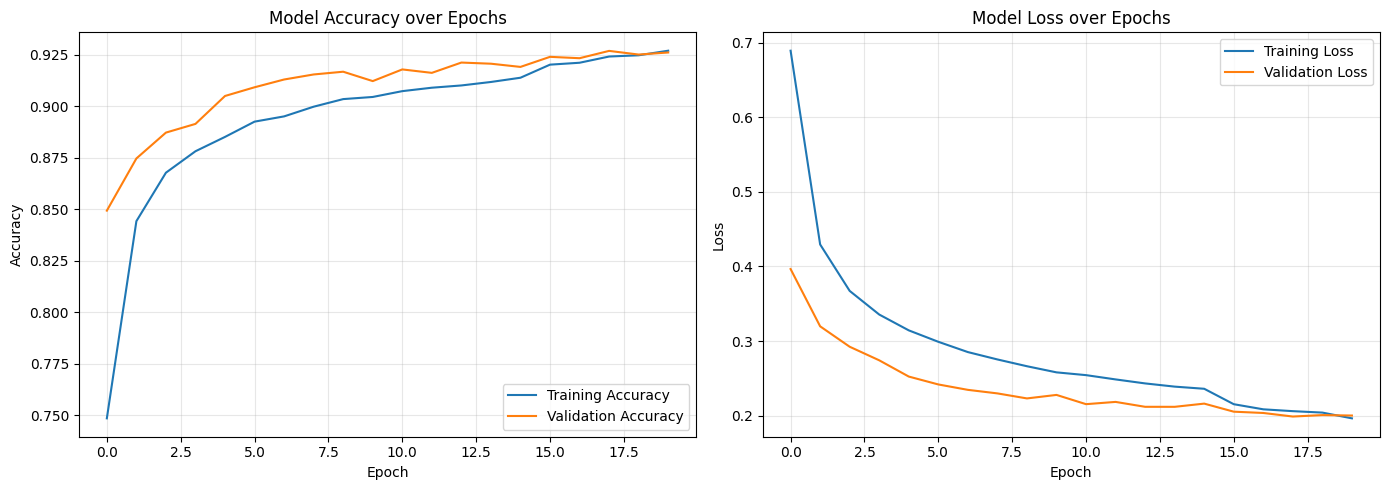

Saved training curves to 'training_curves.png'



In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Saved training curves to 'training_curves.png'\n")

Plot a few test images with predicted vs true labels

In [19]:
plt.figure(figsize=(12, 8))
indices = np.random.choice(len(x_test), 15, replace=False)

<Figure size 1200x800 with 0 Axes>

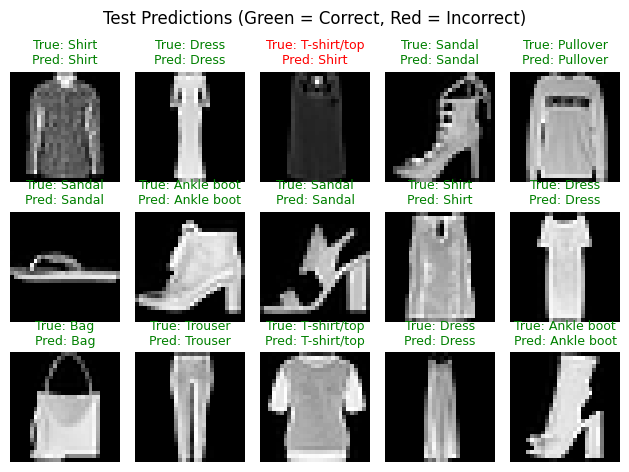

Saved sample predictions to 'sample_predictions.png'



In [20]:
for i, idx in enumerate(indices):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    plt.axis('off')

    plt.suptitle("Test Predictions (Green = Correct, Red = Incorrect)")
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()
print("Saved sample predictions to 'sample_predictions.png'\n")

In [21]:
model.save('fashion_mnist_cnn_model.h5')
print("Model saved as 'fashion_mnist_cnn_model.h5'")

Model saved as 'fashion_mnist_cnn_model.h5'


In [22]:
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 0.9210
Final Test Loss: 0.2143
